<center> <h1> Predictive Targeting in Bank Marketing Campaigns using Deep Learning Architectures and Big Data</h1></center>

In [1]:
import warnings
warnings.filterwarnings('ignore')

# Install Packages
#!python3 -m pip install imblearn hdfs --break-system-packages
#!python3 -m pip install pytorch_tabnet --break-system-packages

In [2]:
# Import Packages
import numpy as np
import pandas as pd
import seaborn as sns
import json
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from pyspark.sql.types import *
from pyspark.sql import functions
from imblearn.over_sampling import SMOTE
from sklearn import metrics
from hdfs import InsecureClient

## Custom Functions

In [3]:
# Save model locally and upload to HDFS
def save_model(model, filename):
    hdfs_path = f'/marketing_campaign/models/{filename}.h5'
    
    print('----Exporting model locally.')
    # Save model locally
    try:
        model.save(f'{filename}.h5')
        print(f'Model was saved locally as {filename}.h5')
    except Exception as e:
        print('Failed to export the model.')
        print('Error details:', e)
        
    
    print('----Uploading model to HDFS.')
    # Upload file to HDFS
    try:
        client = InsecureClient('http://localhost:9870', user='hduser')

        with open(f'{filename}.h5', 'rb') as f:
            client.write(hdfs_path, f, overwrite=True)

        print(f"Model saved to HDFS at {hdfs_path}")
    except Exception as e:
        print('Failed to upload model to HDFS.')
        print('Error details:', e)

## Import Dataset from HDFS

In [4]:
df = spark.read.load('hdfs://localhost:9000/marketing_campaign/train_data/marketing_data.csv', format="csv", header="true")
df.printSchema()

root
 |-- _c0: string (nullable = true)
 |-- age: string (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: string (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day_of_week: string (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: string (nullable = true)
 |-- campaign: string (nullable = true)
 |-- pdays: string (nullable = true)
 |-- previous: string (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- target: string (nullable = true)



In [5]:
data=df.toPandas()
data.head()

25/10/02 18:13:11 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: , age, job, marital, education, default, balance, housing, loan, contact, day_of_week, month, duration, campaign, pdays, previous, poutcome, target
 Schema: _c0, age, job, marital, education, default, balance, housing, loan, contact, day_of_week, month, duration, campaign, pdays, previous, poutcome, target
Expected: _c0 but found: 
CSV file: hdfs://localhost:9000/marketing_campaign/train_data/marketing_data.csv


,_c0,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,target
0,0,58,management,married,tertiary,no,2143,yes,no,None,5,may,261,1,-1,0,None,no
1,1,44,technician,single,secondary,no,29,yes,no,None,5,may,151,1,-1,0,None,no
2,2,33,entrepreneur,married,secondary,no,2,yes,yes,None,5,may,76,1,-1,0,None,no
3,3,47,blue-collar,married,None,no,1506,yes,no,None,5,may,92,1,-1,0,None,no
4,4,33,None,single,None,no,1,no,no,None,5,may,198,1,-1,0,None,no


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   _c0          45211 non-null  object
 1   age          45211 non-null  object
 2   job          44923 non-null  object
 3   marital      45211 non-null  object
 4   education    43354 non-null  object
 5   default      45211 non-null  object
 6   balance      45211 non-null  object
 7   housing      45211 non-null  object
 8   loan         45211 non-null  object
 9   contact      32191 non-null  object
 10  day_of_week  45211 non-null  object
 11  month        45211 non-null  object
 12  duration     45211 non-null  object
 13  campaign     45211 non-null  object
 14  pdays        45211 non-null  object
 15  previous     45211 non-null  object
 16  poutcome     8252 non-null   object
 17  target       45211 non-null  object
dtypes: object(18)
memory usage: 6.2+ MB


In [7]:
data.describe()

,_c0,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,target
count,45211,45211,44923,45211,43354,45211,45211,45211,45211,32191,45211,45211,45211,45211,45211,45211,8252,45211
unique,45211,77,11,3,3,2,7168,2,2,2,31,12,1573,48,559,41,3,2
top,0,32,blue-collar,married,secondary,no,0,yes,no,cellular,20,may,124,1,-1,0,failure,no
freq,1,2085,9732,27214,23202,44396,3514,25130,37967,29285,2752,13766,188,17544,36954,36954,4901,39922


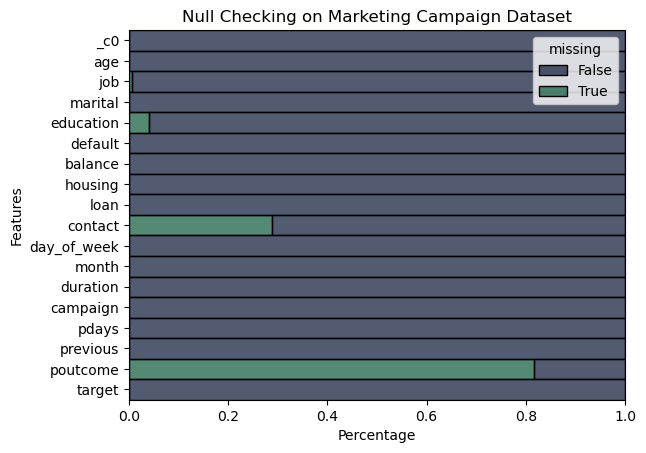

In [8]:
data.isnull().sum()

sns.set_palette('cubehelix')

sns.histplot(data=data.isnull().melt(value_name='missing'),
           y='variable',
           hue='missing',
           multiple='fill')

plt.title('Null Checking on Marketing Campaign Dataset')
plt.xlabel('Percentage')
plt.ylabel('Features')

plt.show()

In [9]:
# Check for duplicates
print(f'Number of duplicates in the dataframe: {data.duplicated().sum()}.')

Number of duplicates in the dataframe: 0.


In [10]:
# Check for unique 
data.nunique()

_c0            45211
age               77
job               11
marital            3
education          3
default            2
balance         7168
housing            2
loan               2
contact            2
day_of_week       31
month             12
duration        1573
campaign          48
pdays            559
previous          41
poutcome           3
target             2
dtype: int64

## Data Preparation and Visualisation

In [11]:
cols = ['age', 'balance', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous']
data[cols] = data[cols].apply(pd.to_numeric, errors='coerce')

In [12]:
try:
    df=data.copy()
    df.drop(columns=['poutcome','_c0','pdays', 'day_of_week','month'], inplace=True)
    df.dropna(axis=0, inplace=True)
    y = df['target']
    X = df.drop(columns=['target'])
except:
    print('No changes made in the dataset.')

X.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
duration     0
campaign     0
previous     0
dtype: int64

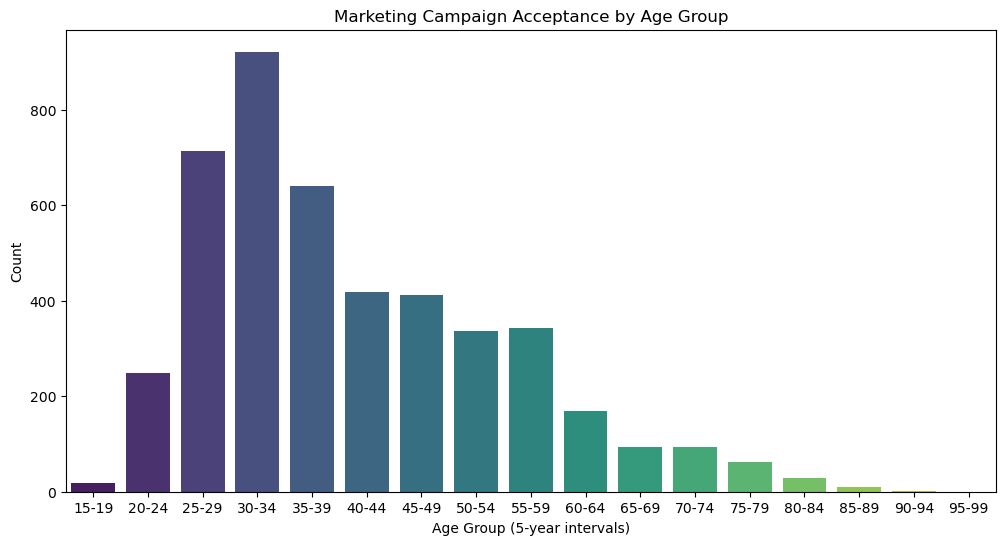

In [38]:
df_yes = df[df['target'] == 'yes'].copy() 

min_age = df_yes['age'].min() // 5 * 5
max_age = (df_yes['age'].max() // 5 + 1) * 5
bins = range(min_age, max_age + 1, 5)
labels = [f"{b}-{b+4}" for b in bins[:-1]]

df_yes['age_group'] = pd.cut(df_yes['age'], bins=bins, labels=labels, right=True)

plt.figure(figsize=(12, 6))
sns.countplot(x='age_group', data=df_yes, order=labels, palette='viridis')
plt.xlabel('Age Group (5-year intervals)')
plt.ylabel('Count')
plt.title('Marketing Campaign Acceptance by Age Group')
plt.show()


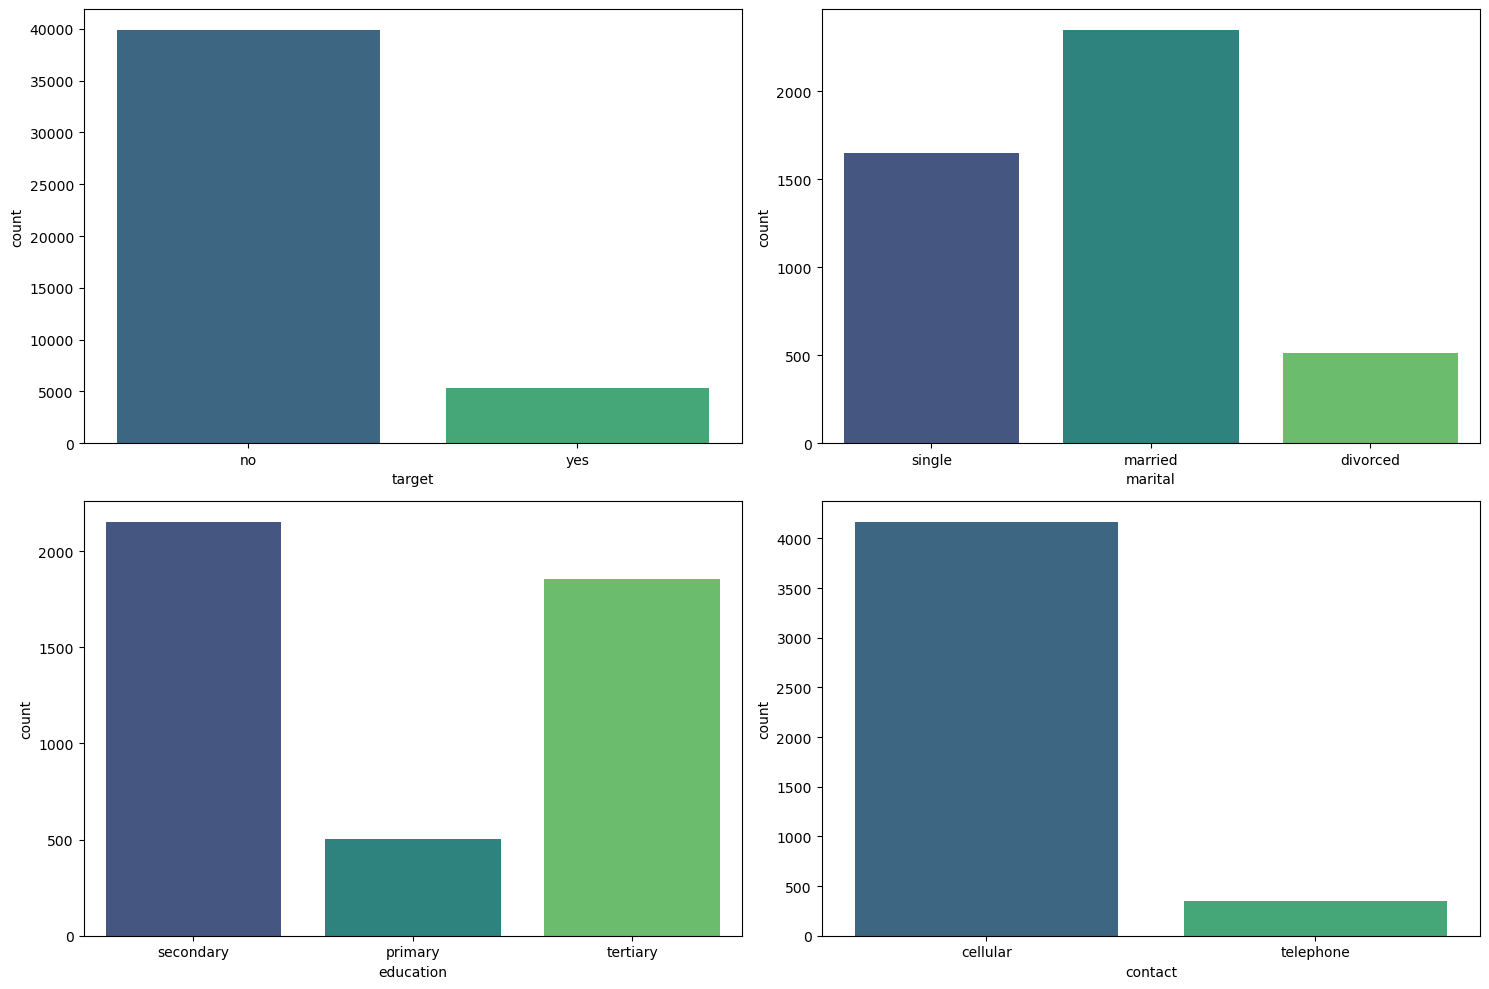

25/10/03 11:36:10 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 59277951 ms exceeds timeout 120000 ms
25/10/03 11:36:11 WARN SparkContext: Killing executors is not supported by current scheduler.
25/10/03 11:36:11 WARN Executor: Issue communicating with driver in heartbeater
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:101)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:85)
	at org.apache.spark.storage.BlockManagerMaster.registerBlockManager(BlockManagerMaster.scala:80)
	at org.apache.spark.storage.BlockManager.reregister(BlockManager.scala:642)
	at org.apache.spark.executor.Executor.reportHeartBeat(Executor.scala:1240)
	at

25/10/03 11:36:21 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$driverEndpoint(BlockManagerMasterEndpoint.scala:123)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.isExecutorAlive$lzycompute$1(BlockManagerMasterEndpoint.scala:688)
	at org.apache.spark.storage.BlockManagerMasterE

25/10/03 11:36:31 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$driverEndpoint(BlockManagerMasterEndpoint.scala:123)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.isExecutorAlive$lzycompute$1(BlockManagerMasterEndpoint.scala:688)
	at org.apache.spark.storage.BlockManagerMasterE

25/10/03 11:36:41 WARN Executor: Issue communicating with driver in heartbeater
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:101)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:85)
	at org.apache.spark.storage.BlockManagerMaster.registerBlockManager(BlockManagerMaster.scala:80)
	at org.apache.spark.storage.BlockManager.reregister(BlockManager.scala:642)
	at org.apache.spark.executor.Executor.reportHeartBeat(Executor.scala:1240)
	at org.apache.spark.executor.Executor.$anonfun$heartbeater$1(Executor.scala:296)
	at scala.runtime.java8.JFunction0$mcV$sp.apply(JFunction0$mcV$sp.java:23)
	at org.apache.spark.util.Utils$.logUncaughtExceptions(Utils.scala:1928)

25/10/03 11:36:51 WARN Executor: Issue communicating with driver in heartbeater
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:101)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:85)
	at org.apache.spark.storage.BlockManagerMaster.registerBlockManager(BlockManagerMaster.scala:80)
	at org.apache.spark.storage.BlockManager.reregister(BlockManager.scala:642)
	at org.apache.spark.executor.Executor.reportHeartBeat(Executor.scala:1240)
	at org.apache.spark.executor.Executor.$anonfun$heartbeater$1(Executor.scala:296)
	at scala.runtime.java8.JFunction0$mcV$sp.apply(JFunction0$mcV$sp.java:23)
	at org.apache.spark.util.Utils$.logUncaughtExceptions(Utils.scala:1928)

25/10/03 11:37:01 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$driverEndpoint(BlockManagerMasterEndpoint.scala:123)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.isExecutorAlive$lzycompute$1(BlockManagerMasterEndpoint.scala:688)
	at org.apache.spark.storage.BlockManagerMasterE

In [45]:

fig, axs = plt.subplots(2, 2, figsize=(15, 10))
axs = axs.flatten() 

sns.countplot(x='marital', data=df_yes, palette='viridis', ax=axs[1])
sns.countplot(x='target', data=data, palette='viridis', ax=axs[0])
sns.countplot(x='education', data=df_yes, palette='viridis', ax=axs[2])
sns.countplot(x='contact', data=df_yes, palette='viridis', ax=axs[3])

plt.tight_layout()
plt.show()


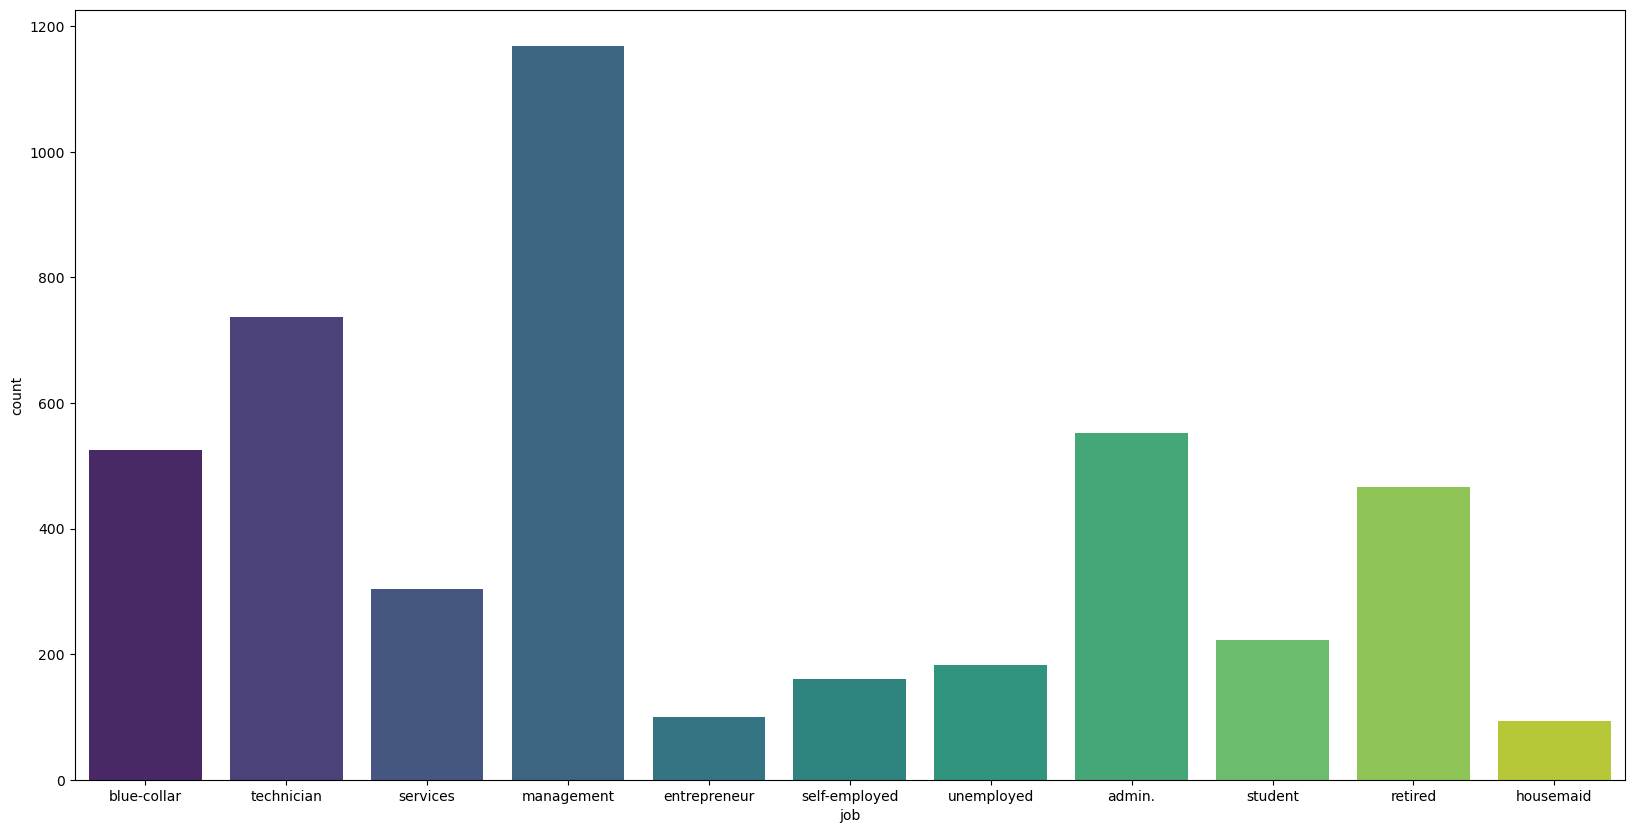

In [43]:
plt.figure(figsize=(20,10))
sns.countplot(x='job', data=df_yes, palette='viridis')
plt.show()

In [19]:
# plt.figure(figsize=(10, 6))

# corr_data=X
# corr_data['target']=y

# # Select only numeric features
# numeric_df = df.select_dtypes(include=['number'])

# sns.heatmap(corr_data.corr(), annot=True, fmt=".1f", cmap='coolwarm')

# plt.title("Correlation Matrix (Numeric Features Only)")
# plt.show()


## Machine Learning

In [20]:

binary_cols = ['default', 'housing', 'loan']
for col in binary_cols:
    X[col] = X[col].map({'yes': 1, 'no': 0})

y=y.map({'yes': 1, 'no': 0})

categorical_cols = ['job', 'marital', 'education']
# One-Hot Encode categorical columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

X.head()


# def label_encoder_df(df):
#     df_encoded = df.copy()
#     le = LabelEncoder()
#     for col in df_encoded.select_dtypes(include=["object"]).columns:
#         df_encoded[col] = le.fit_transform(df_encoded[col])
#     return df_encoded

# X_encoded = label_encoder_df(X)
# y_df = y.to_frame() 
# y_encoded = label_encoder_df(y_df)
# print(X_encoded.head(),'\n', y_encoded.head())

X.columns

Index(['age', 'default', 'balance', 'housing', 'loan', 'duration', 'campaign',
       'previous', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'marital_married',
       'marital_single', 'education_secondary', 'education_tertiary'],
      dtype='object')

In [21]:
y

0        0
1        0
2        0
5        0
6        0
        ..
45206    1
45207    1
45208    1
45209    0
45210    0
Name: target, Length: 43193, dtype: int64

### Smote

In [22]:

# # Split into train and test (important: apply SMOTE only on training data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

pd.Series(y_train).value_counts()


target
0    30537
1     4017
Name: count, dtype: int64

In [24]:
scaler = StandardScaler()
#X_train_scaled = scaler.fit_transform(X_train_res)
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.fit_transform(X_test)


In [25]:
y_train_res

0        0
1        0
2        0
3        0
4        0
        ..
61069    1
61070    1
61071    1
61072    1
61073    1
Name: target, Length: 61074, dtype: int64

In [26]:
model = Sequential([
    Dense(64, input_dim=X_train_scaled.shape[1], activation='relu'), 
    Dropout(0.3),
    Dense(32, activation='relu'),  
    Dropout(0.3),
    Dense(1, activation='sigmoid')                             
])

model.compile(
    optimizer='adam', 
    loss='binary_crossentropy',  # binary classification
    metrics=['accuracy']
)

In [27]:
early_stop = EarlyStopping(
    monitor='val_loss',  
    patience=10,          
    restore_best_weights=True  
)

history = model.fit(
    X_train_scaled, y_train_res,
    validation_split=0.2,
    epochs=50,
    batch_size=100,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8507 - loss: 0.3519 - val_accuracy: 0.9228 - val_loss: 0.1763
Epoch 2/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8834 - loss: 0.2782 - val_accuracy: 0.9202 - val_loss: 0.1715
Epoch 3/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8854 - loss: 0.2672 - val_accuracy: 0.9210 - val_loss: 0.1754
Epoch 4/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8877 - loss: 0.2632 - val_accuracy: 0.9238 - val_loss: 0.1692
Epoch 5/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8885 - loss: 0.2601 - val_accuracy: 0.9221 - val_loss: 0.1674
Epoch 6/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8893 - loss: 0.2579 - val_accuracy: 0.9246 - val_loss: 0.1595
Epoch 7/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8903 - loss: 0.2559 - val_accuracy: 0.9275 - val_loss: 0.1599
Epoch 8/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8914 - loss: 0.2545 - val_accuracy: 0.

In [28]:
loss, accuracy = model.evaluate(X_test_scaled, y_test)
print(f"Test Accuracy: {accuracy*100:.2f}%")

270/270 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6862 - loss: 0.7600
Test Accuracy: 68.62%


In [29]:
result = model.predict(X_test_scaled)

rounded = [round(x[0]) for x in result]

270/270 ━━━━━━━━━━━━━━━━━━━━ 0s 817us/step


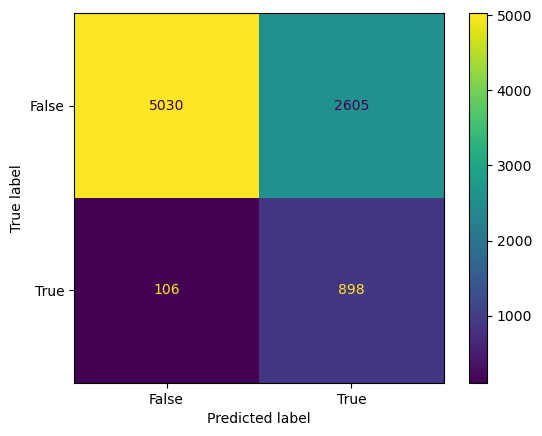

In [30]:
actual = y_test
predicted = rounded

confusion_matrix = metrics.confusion_matrix(actual, rounded)

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])

cm_display.plot()
plt.show() 

In [23]:
save_model(model, 'ann_model')

----Exporting model locally.
Model was saved locally as ann_model.h5
----Uploading model to HDFS.
Model saved to HDFS at /marketing_campaign/models/ann_model.h5
